## **This is testing or experimental notebook for ResNet18 model...**

In [25]:
# Importing the basic libraries

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


# PyTorch stuff
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as tt
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from torchvision.utils import make_grid

%matplotlib inline
matplotlib.rcParams['figure.facecolor'] = '#ffffff' 

In [26]:
# clearning the cache from the GPU
import torch
print("GPU Availability: ", torch.cuda.is_available())

torch.cuda.empty_cache()

GPU Availability:  True


### __*Getting the DATA*__

In [27]:
data_dir = "/home/rikin/brain-tumor-classification/data"

print("Total Files: ", os.listdir(data_dir)) # listing all the files in the directory
print("-"*70)
train_classes = os.listdir(data_dir + '/Training')
test_classes = os.listdir(data_dir + '/Testing')

print("Train Classes: ", train_classes,"\n","Test Classes: ", test_classes)

Total Files:  ['Training', 'archive.zip', 'Testing']
----------------------------------------------------------------------
Train Classes:  ['notumor', 'meningioma', 'glioma', 'pituitary'] 
 Test Classes:  ['notumor', 'meningioma', 'glioma', 'pituitary']


In [28]:
# Total number of samples in train and test data 
print("Total Images:")
print("-"*70)
train_dataset = torchvision.datasets.ImageFolder(root=data_dir + '/Training')
test_dataset = torchvision.datasets.ImageFolder(root=data_dir + '/Testing')

print("Training Dataset Size: ", len(train_dataset),"\n","Testing Dataset Size: ", len(test_dataset))


Total Images:
----------------------------------------------------------------------
Training Dataset Size:  5600 
 Testing Dataset Size:  1600


### __*Data Augmentation*__

In [29]:
# First defining the statistiscs of the data that is compatible with the ResNet18 model, availabel at Official PyTorch Documentation for ResNet18
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

stats = (mean, std)

# defining the transformation for model compatibility
train_trfs = tt.Compose([
    tt.Resize(256), 
    tt.CenterCrop(224),
    #tt.RandomHorizontalFlip(),
    tt.RandomRotation(5),
    tt.ToTensor(), # PIL -> Tensor and Scaled -> [0,1]
    tt.Normalize(*stats, inplace=True)
])

val_trfs = tt.Compose([
    tt.Resize(256),
    tt.CenterCrop(224),
    tt.ToTensor(),
    tt.Normalize(*stats)
])

In [30]:
data_dir

'/home/rikin/brain-tumor-classification/data'

In [31]:
## Applying the transformation using PyTorch ImageFolder class

batch_size = 64

# Datasets
train_dataset = torchvision.datasets.ImageFolder(root=data_dir + '/Training', transform=train_trfs)
test_dataset = torchvision.datasets.ImageFolder(root=data_dir + '/Testing', transform=val_trfs)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=4, pin_memory=True, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=4, pin_memory=True, shuffle=False)

In [32]:
# verify the shape of transformed image
for i in range(5):
    img, label = test_dataset[i]
    print(img.shape)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


In [33]:
for image, label in train_loader:
    print(image.shape)
    print(label.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


> So the Shape is perfect for training...

### __*EDA and Visualization of the Dataset*__

In [34]:
def denormalize(img, means, stds):
    means = torch.tensor(means).reshape(1,3,1,1)
    stds = torch.tensor(stds).reshape(1,3,1,1)
    return img * stds + means

# Show a batch of images
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, *stats)
        ax.imshow(make_grid(denorm_images[:36], nrow=6).permute(1,2,0).clamp(0,1))
        break

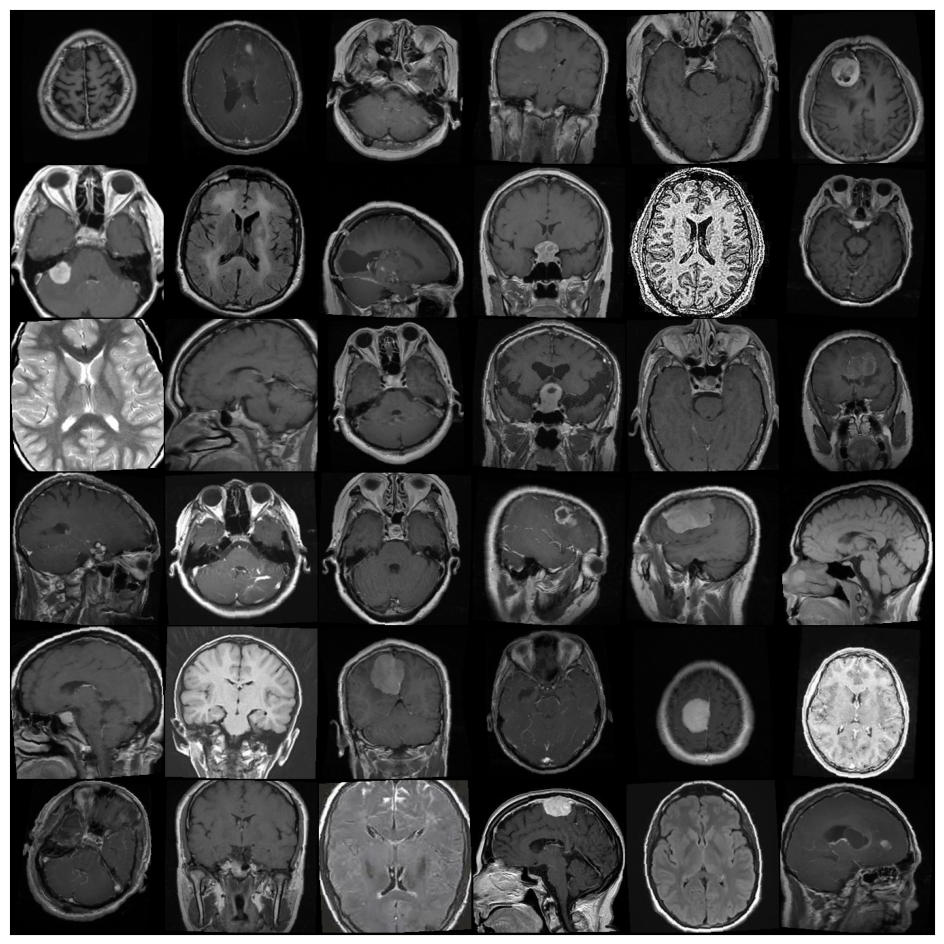

In [35]:
show_batch(train_loader)

### __*Now our Data is ready for training using Transfer Learning from ResNet18 Model...*__


In [36]:
# importing the model
import torchvision.models as models

resnet18 = models.resnet18(pretrained=True)

/home/rikin/brain-tumor-classification/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rikin/brain-tumor-classification/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
# Model Architecture
resnet18.parameters

<bound method Module.parameters of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [38]:
resnet18.fc

Linear(in_features=512, out_features=1000, bias=True)

In [39]:
# Unfreeze the parameters 
for param in resnet18.parameters():
    param.requires_grad=False

In [40]:
# replacing the final fully connected layer with custom logic.
resnet18.fc = nn.Sequential(
    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=256, out_features=4)
)

In [41]:
print("Final ResNet18 Architecture....")
print("\n")
print("-"*70)
resnet18

Final ResNet18 Architecture....


----------------------------------------------------------------------


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
# moving the model and data_loaders to GPU for faster traning
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [43]:
resnet18 = resnet18.to(device)

In [57]:
# setting the hyperparameters for training the model

learning_rate = 0.00001
epochs = 25

# loss function
criterion = nn.CrossEntropyLoss()

#  Optimizer
optimizer = torch.optim.Adam(resnet18.fc.parameters(), lr=learning_rate, weight_decay=1e-4)

# Scheudler
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

### __*Defining the Training Loop*__

In [ ]:
for epoch in range(epochs):

    resnet18.train() #model training mode

    total_epoch_loss = 0
    correct = 0
    total = 0

    for batch_images, batch_labels in train_loader:

        # moving the imgs and labels in GPU 
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        outputs = resnet18(batch_images)

        # Loss
        loss = criterion(outputs, batch_labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()      # Backpropagation 

        # update gradients
        optimizer.step()

        # Adding loss
        total_epoch_loss = total_epoch_loss + loss.item()

        # accuracy
        _, predicted = torch.max(outputs, 1)
        correct = correct + (predicted == batch_labels).sum().item()
        total = total + batch_labels.size(0) 

    # scheduler for tuning lr
    #scheduler.step()

    # loss and accuracy
    avg_loss = total_epoch_loss/len(train_loader)
    accuracy = correct / total


    print(f"Epoch: {epoch + 1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch: 1, Loss: 0.1024, Accuracy: 0.9632
Epoch: 2, Loss: 0.0977, Accuracy: 0.9679
Epoch: 3, Loss: 0.1055, Accuracy: 0.9643
Epoch: 4, Loss: 0.0972, Accuracy: 0.9689
Epoch: 5, Loss: 0.0941, Accuracy: 0.9657


### __*Got loss about 0.28 in first 25 epochs training for another 25 Epochs*__

### __*After 50 Epochs loss is about 0.22*__

## Let's Evaluate on Test Data using Accuracy Metric

In [59]:
total = 0
correct = 0

with torch.no_grad():

    for batch_images, batch_labels in train_loader:

        # move to gpu
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # results or outputs
        outputs = resnet18(batch_images)

        # accuracy metric

        _, preds = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]
        correct = correct + (preds == batch_labels).sum().item()

    print(correct/total)

0.9710714285714286


In [60]:
resnet18.eval()

total = 0
correct = 0

with torch.no_grad():

    for batch_images, batch_labels in test_loader:

        # move to gpu
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # results or outputs
        outputs = resnet18(batch_images)

        # accuracy metric

        _, preds = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]
        correct = correct + (preds == batch_labels).sum().item()

    print(correct/total)

0.895625


### __*We got around **~96%** accuracy on Training data and **~89%** ON Test data, which is a Good sign and can further examine by other metris like Precision, Recall and F1-score.*__

In [61]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

resnet18.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [62]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81       400
           1       0.81      0.91      0.86       400
           2       0.90      1.00      0.95       400
           3       0.94      0.96      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



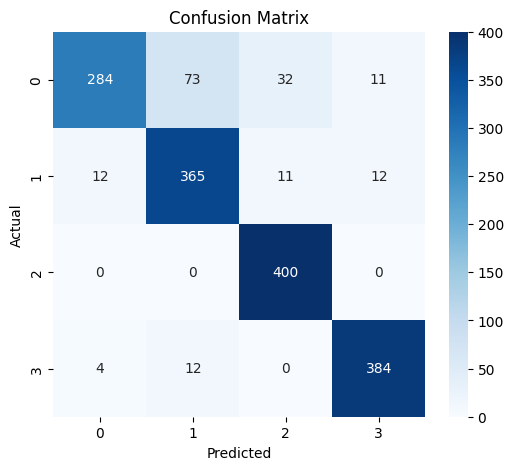

In [65]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [72]:
class_names = train_dataset.classes
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

### __*So this model is actually good, and can be used for testing*__

In [99]:
# function for testing on one single image
from PIL import Image

def predict_tumor(model, image_path, transform, class_names, device):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    img_tensor = transform(image)
    img_tensor = img_tensor.unsqueeze(0)
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)


        conf, pred = torch.max(probs, 1)
    
    predicted_class = class_names[pred.item()]
    confidence = conf.item()

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class}, Confidence: {confidence*100:.2f} %")
    plt.axis("on")
    plt.show()
    
    return predicted_class, confidence, probs.detach().cpu().numpy()


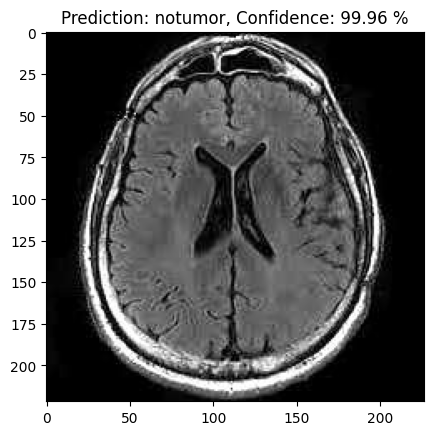

In [101]:
pred_class, conf, probs = predict_tumor(resnet18,
                                        "/home/rikin/brain-tumor-classification/data/Testing/notumor/Te-no_395.jpg",
                                        val_trfs,
                                        class_names,
                                        device)


## __*This model is actually very good in predicting the Tumor. So let's save this model for further deployment.*__

In [114]:
! pwd
! cd ../
!pwd

/home/rikin/brain-tumor-classification/notebooks
/home/rikin/brain-tumor-classification/notebooks


zsh:cd:1: no such file or directory: models


In [116]:
## model saave
import json

torch.save({
    'model_state_dict':resnet18.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': 4,
    'class_names': train_dataset.classes
}, "/home/rikin/brain-tumor-classification/models/checkpoints.pth")


with open("/home/rikin/brain-tumor-classification/models/classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

In [120]:
# For loading the model:::

import torch
import json
import torchvision.models as models
import torch.nn as nn

# Recreate model architecture
resnet18 = models.resnet18(pretrained=False)

num_features = resnet18.fc.in_features
resnet18.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 4)
)

# Load checkpoint
checkpoint = torch.load("/home/rikin/brain-tumor-classification/models/checkpoints.pth")

resnet18.load_state_dict(checkpoint['model_state_dict'])
resnet18 = resnet18.to(device)
resnet18.eval()

# Load class names
with open("/home/rikin/brain-tumor-classification/models/classes.json", "r") as f:
    class_names = json.load(f)

print("Model and classes loaded successfully!")

Model and classes loaded successfully!
